# SupportOps AI - Baseline Ticket Classification

## Objective

Build a baseline NLP classification model that predicts the type of a
customer support ticket from its text.

### Pipeline

Ticket Text → TF-IDF → Logistic Regression → Ticket Type

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
DATA_PATH = "../data/processed/ticket_classification_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (8469, 3)


,ticket_id,ticket_text,ticket_type
0,1,Product setup I'm having an issue with the {pr...,Technical issue
1,2,Peripheral compatibility I'm having an issue w...,Technical issue
2,3,Network problem I'm facing a problem with my {...,Technical issue
3,4,Account access I'm having an issue with the {p...,Billing inquiry
4,5,Data loss I'm having an issue with the {produc...,Billing inquiry


Verify the data before training

In [3]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTicket classes:")
print(df["ticket_type"].value_counts())

Dataset shape: (8469, 3)

Missing values:
ticket_id      0
ticket_text    0
ticket_type    0
dtype: int64

Ticket classes:
ticket_type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


In [4]:
X = df["ticket_text"]
y = df["ticket_type"]

In [5]:
print("Input examples:", X.shape[0])
print("Target examples:", y.shape[0])

Input examples: 8469
Target examples: 8469


Split the dataset

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 6775
Testing samples: 1694


Verify stratification

In [8]:
train_distribution = (
    y_train.value_counts(normalize=True) * 100
)

test_distribution = (
    y_test.value_counts(normalize=True) * 100
)

distribution_comparison = pd.DataFrame({
    "Train %": train_distribution,
    "Test %": test_distribution
})

distribution_comparison

,Train %,Test %
ticket_type,,
Refund request,20.678967,20.720189
Technical issue,20.634686,20.602125
Cancellation request,20.014760,20.011806
Product inquiry,19.380074,19.362456
Billing inquiry,19.291513,19.303424


Create the TF-IDF vectorizer

In [9]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

Build the Pipeline

In [10]:
baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

Train the model

In [11]:
baseline_model.fit(
    X_train,
    y_train
)

print("Baseline model trained successfully!")

Baseline model trained successfully!


Generate Predictions

In [12]:
y_pred = baseline_model.predict(X_test)

print("Predictions generated!")

Predictions generated!


Calculating accuracy score

In [14]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.2048


Precision, Recall and F1

In [15]:
precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Macro F1:  {f1:.4f}")

Accuracy:  0.2048
Precision: 0.2053
Recall:    0.2049
Macro F1:  0.2050


Generating full classification report

In [16]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

                      precision    recall  f1-score   support

     Billing inquiry     0.2074    0.2049    0.2062       327
Cancellation request     0.2118    0.2006    0.2061       339
     Product inquiry     0.2166    0.2073    0.2118       328
      Refund request     0.1791    0.1852    0.1821       351
     Technical issue     0.2118    0.2264    0.2188       349

            accuracy                         0.2048      1694
           macro avg     0.2053    0.2049    0.2050      1694
        weighted avg     0.2051    0.2048    0.2049      1694



Creating the confusion matrix

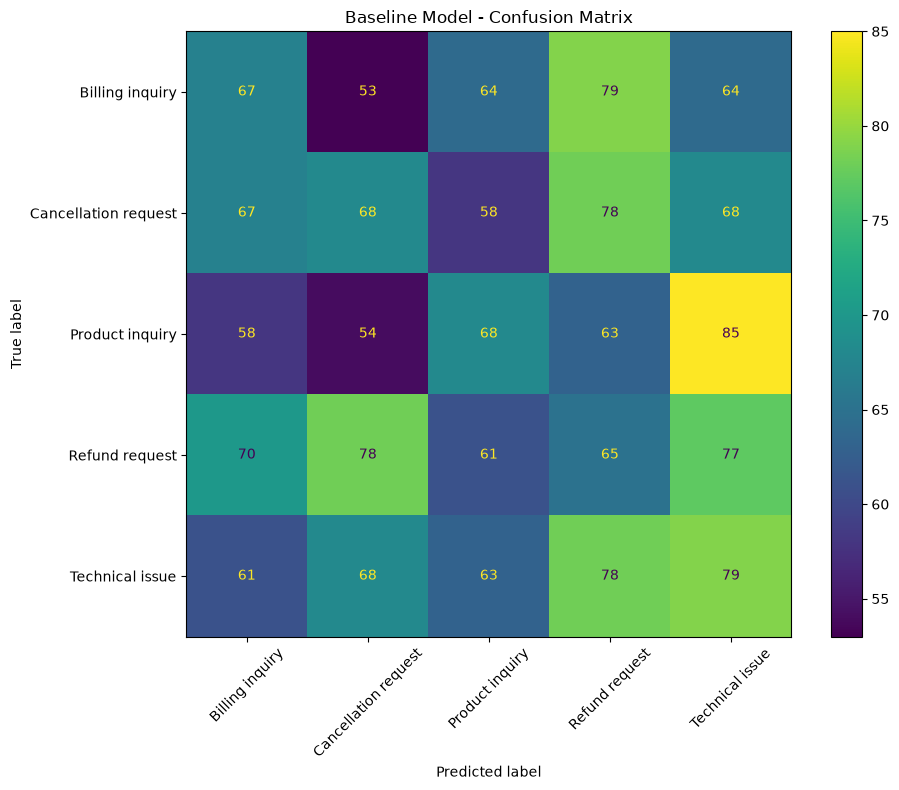

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45,
    ax=ax
)

plt.title("Baseline Model - Confusion Matrix")
plt.tight_layout()
plt.show()

Creating a compact metrics table

In [18]:
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics_df

,Metric,Score
0,Accuracy,0.204841
1,Macro Precision,0.205338
2,Macro Recall,0.204869
3,Macro F1,0.204992


Inspect actual predictions

In [19]:
results_df = pd.DataFrame({
    "ticket_text": X_test,
    "actual": y_test,
    "predicted": y_pred
})

results_df.head(10)

,ticket_text,actual,predicted
6510,Installation support I'm having an issue with ...,Product inquiry,Cancellation request
4921,Refund request I'm having an issue with the {p...,Refund request,Cancellation request
871,Cancellation request I'm having an issue with ...,Billing inquiry,Cancellation request
6086,Account access I'm having an issue with the {p...,Product inquiry,Billing inquiry
3305,Cancellation request I'm having an issue with ...,Refund request,Cancellation request
7739,Peripheral compatibility I'm having an issue w...,Cancellation request,Technical issue
6339,Refund request I'm having an issue with the {p...,Technical issue,Cancellation request
7811,Network problem I'm having an issue with the {...,Technical issue,Product inquiry
6844,Delivery problem I'm facing issues logging int...,Refund request,Billing inquiry
563,Battery life I'm having an issue with the {pro...,Billing inquiry,Cancellation request


In [20]:
errors_df = results_df[
    results_df["actual"] != results_df["predicted"]
]

print("Number of incorrect predictions:", len(errors_df))

errors_df.head(20)

Number of incorrect predictions: 1347


,ticket_text,actual,predicted
6510,Installation support I'm having an issue with ...,Product inquiry,Cancellation request
4921,Refund request I'm having an issue with the {p...,Refund request,Cancellation request
871,Cancellation request I'm having an issue with ...,Billing inquiry,Cancellation request
6086,Account access I'm having an issue with the {p...,Product inquiry,Billing inquiry
3305,Cancellation request I'm having an issue with ...,Refund request,Cancellation request
7739,Peripheral compatibility I'm having an issue w...,Cancellation request,Technical issue
6339,Refund request I'm having an issue with the {p...,Technical issue,Cancellation request
7811,Network problem I'm having an issue with the {...,Technical issue,Product inquiry
6844,Delivery problem I'm facing issues logging int...,Refund request,Billing inquiry
563,Battery life I'm having an issue with the {pro...,Billing inquiry,Cancellation request


Inspect individual mistakes

In [21]:
for _, row in errors_df.head(5).iterrows():

    print("=" * 80)

    print("TICKET:")
    print(row["ticket_text"])

    print("\nACTUAL:")
    print(row["actual"])

    print("\nPREDICTED:")
    print(row["predicted"])

    print()

TICKET:
Installation support I'm having an issue with the {product_purchased}. Please assist. This problem started occurring after the recent software update. I haven't made any other changes to the device.

ACTUAL:
Product inquiry

PREDICTED:
Cancellation request

TICKET:
Refund request I'm having an issue with the {product_purchased}. Please assist. I've recently updated the firmware of my {product_purchased}, and the issue started happening afterward. Could it be related to the update?

ACTUAL:
Refund request

PREDICTED:
Cancellation request

TICKET:
Cancellation request I'm having an issue with the {product_purchased}. Please assist. This problem started occurring after the recent software update. I haven't made any other changes to the device.

ACTUAL:
Billing inquiry

PREDICTED:
Cancellation request

TICKET:
Account access I'm having an issue with the {product_purchased}. Please assist. {product_name}'s "Product Name" contains a product identifier, which you can use to verify the

In [22]:
train_texts = set(X_train)
test_texts = set(X_test)

overlap = train_texts.intersection(test_texts)

print(
    "Exact ticket texts appearing in both train and test:",
    len(overlap)
)

Exact ticket texts appearing in both train and test: 29


29 exact ticket texts appear in both your training set and your test set. That means our current evaluation has a small amount of train–test leakage, so we should fix it before trusting the baseline metrics.

In [23]:
overlap_texts = train_texts.intersection(test_texts)

print("Number of overlapping texts:", len(overlap_texts))

for text in list(overlap_texts)[:10]:
    print("=" * 80)
    print(text)

Number of overlapping texts: 29
Peripheral compatibility I'm having an issue with the {product_purchased}. Please assist. I'm unable to find the option to perform the desired action in the {product_purchased}. Could you please guide me through the steps?
Display issue I'm having an issue with the {product_purchased}. Please assist. I've noticed that the issue occurs consistently when I use a specific feature or application on my {product_purchased}.
Network problem I'm having an issue with the {product_purchased}. Please assist. I'm experiencing this issue on multiple devices of the same model, so it seems to be a widespread problem.
Product recommendation I'm having an issue with the {product_purchased}. Please assist. I rely heavily on my {product_purchased} for my daily tasks, and this issue is hindering my productivity.
Refund request I'm having an issue with the {product_purchased}. Please assist. I need assistance as soon as possible because it's affecting my work and productivit

Check whether identical text has the same or different label

In [24]:
duplicate_label_check = (
    df.groupby("ticket_text")["ticket_type"]
      .nunique()
)

conflicting_texts = duplicate_label_check[
    duplicate_label_check > 1
]

print(
    "Exact same texts having different labels:",
    len(conflicting_texts)
)

Exact same texts having different labels: 85


Clean the conflicts properly

In [25]:
conflicting_text_values = set(
    conflicting_texts.index
)

clean_model_df = df[
    ~df["ticket_text"].isin(
        conflicting_text_values
    )
].copy()

print("Before conflict removal:", df.shape)
print("After conflict removal:", clean_model_df.shape)

Before conflict removal: (8469, 3)
After conflict removal: (8264, 3)


In [26]:
clean_model_df = clean_model_df.drop_duplicates(
    subset=["ticket_text"]
).copy()

print(
    "After duplicate removal:",
    clean_model_df.shape
)

After duplicate removal: (8240, 3)


In [27]:
print(
    "Duplicate texts remaining:",
    clean_model_df.duplicated(
        subset=["ticket_text"]
    ).sum()
)

Duplicate texts remaining: 0


verify that there are no remaining conflicting labels

In [28]:
remaining_conflicts = (
    clean_model_df
    .groupby("ticket_text")["ticket_type"]
    .nunique()
)

remaining_conflicts = remaining_conflicts[
    remaining_conflicts > 1
]

print(
    "Remaining conflicting texts:",
    len(remaining_conflicts)
)

Remaining conflicting texts: 0


recreate X and y

In [29]:
X = clean_model_df["ticket_text"]
y = clean_model_df["ticket_type"]

Split again

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Checking overlap again

In [31]:
train_texts = set(X_train)
test_texts = set(X_test)

overlap = train_texts.intersection(test_texts)

print(
    "Exact ticket texts appearing in both train and test:",
    len(overlap)
)

Exact ticket texts appearing in both train and test: 0


Retrain the corrected baseline

In [32]:
baseline_model.fit(
    X_train,
    y_train
)

print("Baseline model retrained successfully!")

Baseline model retrained successfully!


generate predictions

In [33]:
y_pred = baseline_model.predict(X_test)

print("Predictions generated!")

Predictions generated!


calculate the corrected metrics

In [34]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Accuracy:        {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall:    {recall:.4f}")
print(f"Macro F1:        {f1:.4f}")

Accuracy:        0.1954
Macro Precision: 0.1963
Macro Recall:    0.1954
Macro F1:        0.1953


detailed report

In [35]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

                      precision    recall  f1-score   support

     Billing inquiry     0.2265    0.2188    0.2226       320
Cancellation request     0.1905    0.1585    0.1730       328
     Product inquiry     0.1924    0.1906    0.1915       320
      Refund request     0.1697    0.1906    0.1796       341
     Technical issue     0.2022    0.2183    0.2099       339

            accuracy                         0.1954      1648
           macro avg     0.1963    0.1954    0.1953      1648
        weighted avg     0.1960    0.1954    0.1952      1648



new confusion matrix

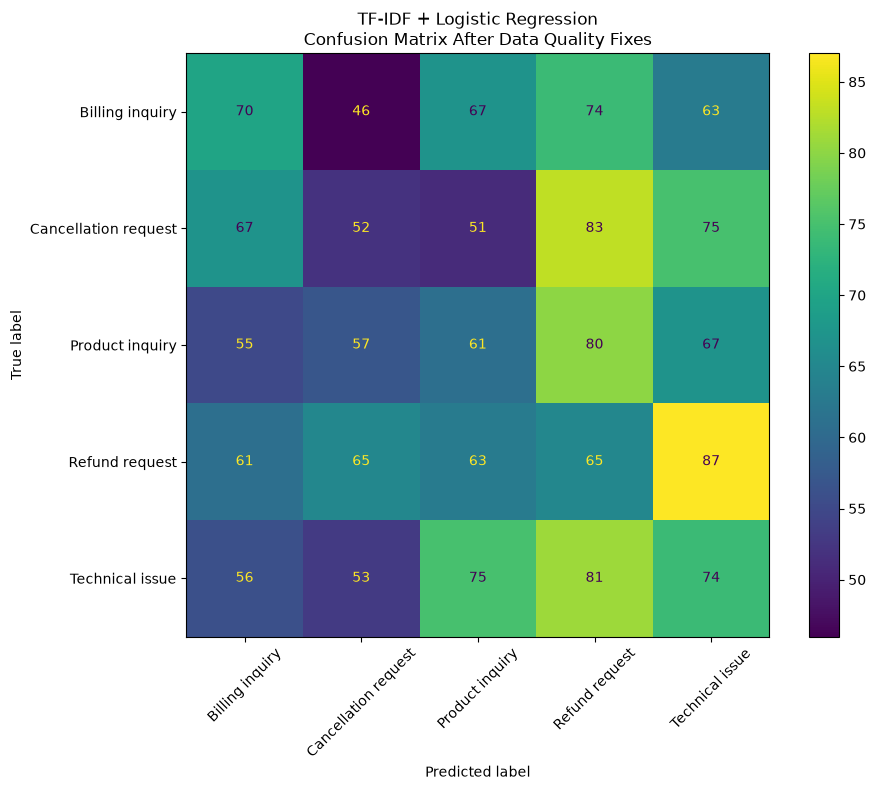

In [36]:
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45,
    ax=ax
)

plt.title(
    "TF-IDF + Logistic Regression\n"
    "Confusion Matrix After Data Quality Fixes"
)

plt.tight_layout()
plt.show()

recreate error analysis

In [37]:
results_df = pd.DataFrame({
    "ticket_text": X_test,
    "actual": y_test,
    "predicted": y_pred
})

errors_df = results_df[
    results_df["actual"]
    != results_df["predicted"]
].copy()

print(
    "Correct predictions:",
    len(results_df) - len(errors_df)
)

print(
    "Incorrect predictions:",
    len(errors_df)
)

Correct predictions: 322
Incorrect predictions: 1326


In [38]:
for _, row in errors_df.head(10).iterrows():

    print("=" * 80)

    print("TICKET:")
    print(row["ticket_text"])

    print("\nACTUAL:")
    print(row["actual"])

    print("\nPREDICTED:")
    print(row["predicted"])

    print()

TICKET:
Refund request I'm having an issue with the {product_purchased}. Please assist. You are also in luck this day. ifferentium is finally making a big debut and I can't stop enjoying the game without you. Y I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.

ACTUAL:
Refund request

PREDICTED:
Technical issue

TICKET:
Product compatibility I'm having an issue with the {product_purchased}. Please assist. I'll probably send in an invoice, but when I figure that out I may need to ask for a refund or to send an additional order. The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.

ACTUAL:
Technical issue

PREDICTED:
Billing inquiry

TICKET:
Display issue There seems to be a glitch in the {product_purchased} software. It freezes frequently, making it difficult to use. Can you please provide a solution? - My question is: How can I safely disable this annoying I've performed a factory re

In [39]:
def get_prediction_details(text):

    probabilities = baseline_model.predict_proba(
        [text]
    )[0]

    classes = baseline_model.classes_

    probability_df = pd.DataFrame({
        "ticket_type": classes,
        "probability": probabilities
    })

    return probability_df.sort_values(
        "probability",
        ascending=False
    )

In [40]:
sample_error = errors_df.iloc[0]

print("Ticket:")
print(sample_error["ticket_text"])

print("\nActual:")
print(sample_error["actual"])

print("\nPredicted:")
print(sample_error["predicted"])

get_prediction_details(
    sample_error["ticket_text"]
)

Ticket:
Refund request I'm having an issue with the {product_purchased}. Please assist. You are also in luck this day. ifferentium is finally making a big debut and I can't stop enjoying the game without you. Y I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.

Actual:
Refund request

Predicted:
Technical issue


,ticket_type,probability
4,Technical issue,0.260868
1,Cancellation request,0.206355
0,Billing inquiry,0.193741
2,Product inquiry,0.175852
3,Refund request,0.163184


In [41]:
full_df = pd.read_csv(
    "../data/processed/customer_support_tickets_clean.csv"
)

In [42]:
pd.crosstab(
    full_df["ticket_subject"],
    full_df["ticket_type"]
)

ticket_type,Billing inquiry,Cancellation request,Product inquiry,Refund request,Technical issue
ticket_subject,,,,,
Account access,103,92,107,108,99
Battery life,106,104,101,119,112
Cancellation request,82,103,85,109,108
Data loss,89,115,91,97,99
Delivery problem,115,114,109,107,116
Display issue,91,103,80,99,105
Hardware issue,100,109,106,129,103
Installation support,108,99,99,119,105
Network problem,95,102,113,107,122


In [43]:
subjects_to_check = [
    "Refund request",
    "Cancellation request",
    "Installation support",
    "Product setup",
    "Account access"
]

for subject in subjects_to_check:
    
    if subject in full_df["ticket_subject"].values:
        
        print("\n", "=" * 60)
        print("SUBJECT:", subject)
        print("=" * 60)
        
        print(
            full_df[
                full_df["ticket_subject"] == subject
            ]["ticket_type"].value_counts()
        )


SUBJECT: Refund request
ticket_type
Cancellation request    126
Product inquiry         122
Refund request          119
Technical issue         109
Billing inquiry         100
Name: count, dtype: int64

SUBJECT: Cancellation request
ticket_type
Refund request          109
Technical issue         108
Cancellation request    103
Product inquiry          85
Billing inquiry          82
Name: count, dtype: int64

SUBJECT: Installation support
ticket_type
Refund request          119
Billing inquiry         108
Technical issue         105
Cancellation request     99
Product inquiry          99
Name: count, dtype: int64

SUBJECT: Product setup
ticket_type
Technical issue         113
Cancellation request    108
Billing inquiry         104
Refund request          104
Product inquiry         100
Name: count, dtype: int64

SUBJECT: Account access
ticket_type
Refund request          108
Product inquiry         107
Billing inquiry         103
Technical issue          99
Cancellation request     92
